In [1]:
import pytz
from datetime import datetime
from dateutil.relativedelta import relativedelta
from skyfield.api import load, wgs84, EarthSatellite

## Standard satellite TLE query

In [2]:
# Download satellite TLE data from NORAD
stations_url = 'https://www.celestrak.com/NORAD/elements/stations.txt'
satellites = load.tle_file(stations_url)
by_name = {sat.name: sat for sat in satellites}

In [3]:
ts = load.timescale()
# satellite = EarthSatellite(line1, line2, 'HST', ts)
satellite=by_name['ISS (NAUKA)']
print(satellite)

# Get the current time in a timezone-aware fashion.

tz = pytz.timezone('UTC')
dt = tz.localize(datetime.utcnow())
print(f"Exectution time: {dt:%Y-%m-%d %H:%M:%S %Z}\n")

# Split the next 200 minutes into a collection of 101-evenly
# spaced Timescales (every two minutes, plus endpoints)

t0 = ts.utc(dt)
t1 = ts.utc(dt + relativedelta(minutes=100))
timescales = ts.linspace(t0, t1, 1000)

# calculate the subpoints.

geocentrics = satellite.at(timescales)
points= wgs84.subpoint_of(geocentrics)

ISS (NAUKA) catalog #49044 epoch 2024-02-23 18:42:33 UTC
Exectution time: 2024-02-24 10:59:52 UTC



In [4]:
longitude=(points.longitude.degrees)
latitude=(points.latitude.degrees)

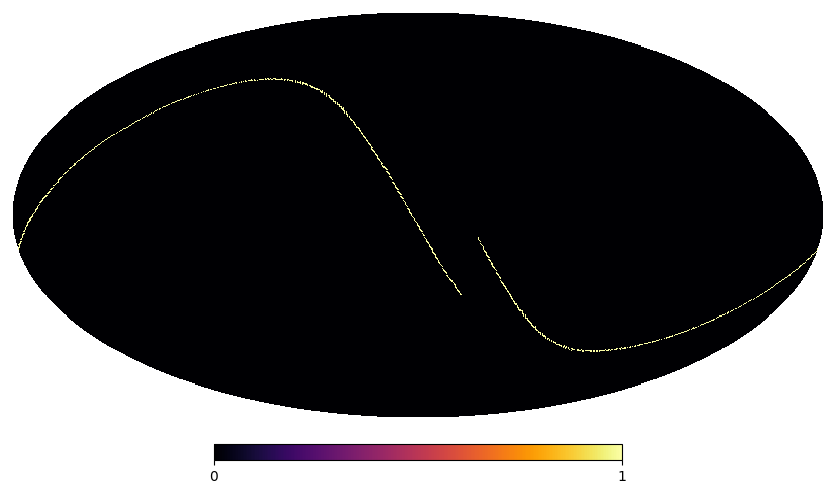

In [5]:
from src2.shapecheck import shapecheck
shapecheck(longitude,latitude,'')

## Customize satellite with self defined orbital elements

In [14]:
ts = load.timescale()

# Updated version of the listed two-line elements

line1 = '1 25544U 98067A   22078.05453850  .00006165  00000+0  11806-3 0  9995'
line2 = '2 25544  51.6427  62.9786 0003909 284.2254 162.3984 15.49468773331209'
satellite = EarthSatellite(line1, line2, 'Pratush', ts)
print(satellite)

# Get the current time in a timezone-aware fashion.

tz = pytz.timezone('UTC')
dt = tz.localize(datetime.utcnow())
print(f"Exectution time: {dt:%Y-%m-%d %H:%M:%S %Z}\n")

# Split the next 200 minutes into a collection of 101-evenly
# spaced Timescales (every two minutes, plus endpoints)

t0 = ts.utc(dt)
t1 = ts.utc(dt + relativedelta(minutes=200))
timescales = ts.linspace(t0, t1, 101)

# calculate the subpoints.

geocentrics = satellite.at(timescales)
subpoints = wgs84.subpoint_of(geocentrics)

Pratush catalog #25544 epoch 2022-03-19 01:18:32 UTC
Exectution time: 2024-02-24 11:07:14 UTC



In [15]:
Lon,Lat=subpoints.longitude.degrees,subpoints.latitude.degrees

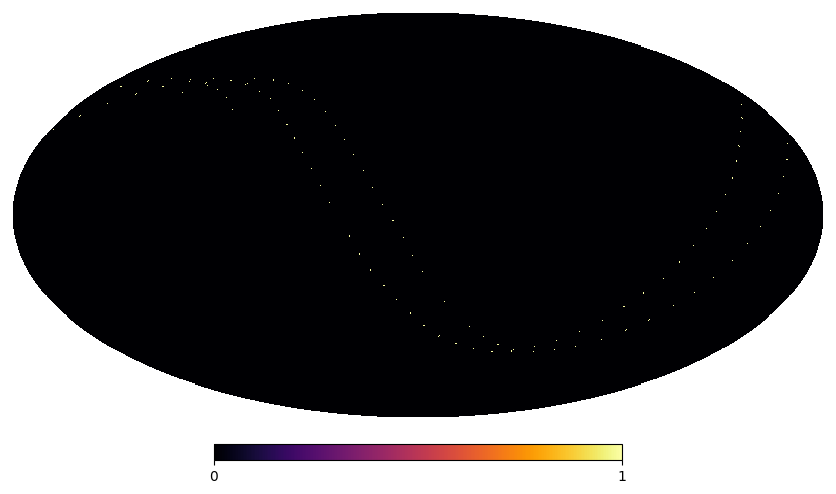

In [16]:
from src2.shapecheck import shapecheck
shapecheck(Lon,Lat,'')

In [20]:
satellite.ITRF_position_velocity_error(t=10)

AttributeError: 'int' object has no attribute 'whole'